In [9]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb

import sys
sys.path.append('../../../src/')
from build_model import resnet50_yichen
from train_functions import train_epochs
from dataset_functions import hdf5_dataset, list_to_dict, viz_dataloader, split_train_valid, verify_image_in_hdf5_file
from visualization_functions import show_images

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


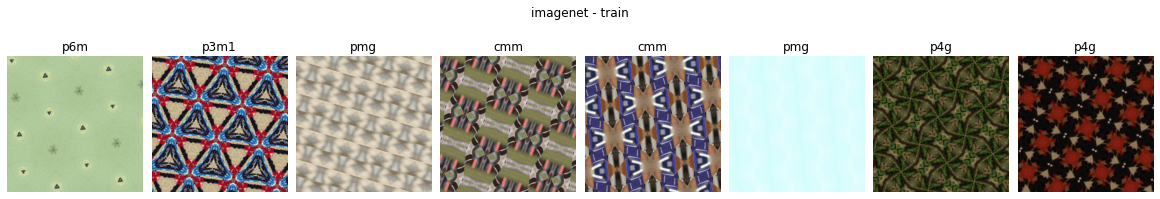

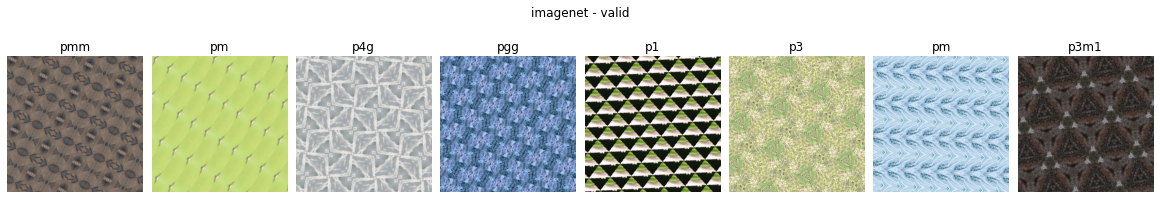

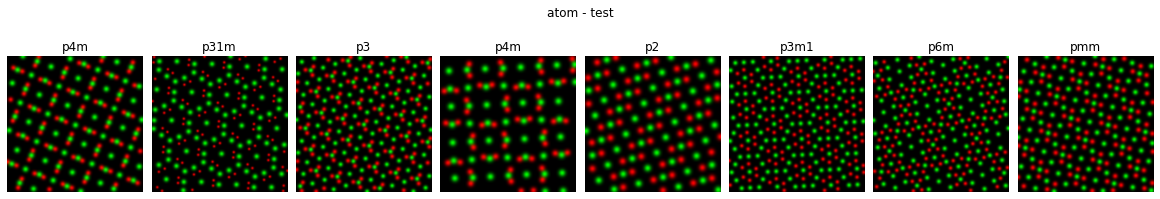

In [13]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

imagenet_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_100k_subset.h5', folder='imagenet', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

# imagenet - train
train_dl = DataLoader(train_ds, batch_size=128, shuffle=False, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')

# imagenet - valid
valid_dl = DataLoader(valid_ds, batch_size=128, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
test_ds = hdf5_dataset('/scratch/yichen/imagenet_v4_rot_10m_100k_subset.h5', folder='atom', transform=transforms.ToTensor())
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test')

In [15]:
model = resnet50_yichen(in_channels=3, n_classes=17, pretrained=False)
print(model(torch.randn(2,3,256,256)).shape)

/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/scratch/yichen/anaconda3/envs/gyc/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


torch.Size([2, 17])


In [16]:
config = {
    'dataset': '10 million datasets',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '01162024-Cross_Validation-resnet50-v4_100K_Subset-ImageNet-Atom'

# train

In [17]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [18]:
device = torch.device('cuda:2')
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, 
                            steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl,
                       epochs=epochs, start=start, scheduler=scheduler, model_name=NAME, 
                       model_dir='../../../saved_models/', tracking=True)

Epoch: 1/20


  0%|          | 0/625 [00:00<?, ?it/s]

100%|██████████| 625/625 [02:11<00:00,  4.75it/s]


Training: Loss: 3.0305, Accuracy: 6.0750%, Time: 2.1936mins


100%|██████████| 157/157 [00:15<00:00, 10.31it/s]


...

Training: Loss: 0.0827, Accuracy: 97.3037%, Time: 2.1052mins


100%|██████████| 157/157 [00:14<00:00, 10.56it/s]


Validation : Loss : 0.2230, Accuracy: 92.6150%, Time: 0.25mins


100%|██████████| 782/782 [01:12<00:00, 10.79it/s]


Validation : Loss : 5.5434, Accuracy: 31.4460%, Time: 1.21mins


# analyze

In [8]:
# model = torch.load('/scratch/yichen/models/05312023-benchmark-resnet50_from_scratch-v4_10m-epoch-19.pt')

# NAME = 'benchmark-resnet50_from_scratch-v4_10m-05312023'
# symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
#                     'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']                  

In [9]:
device = torch.device('cuda:0')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

100%|██████████| 43479/43479 [2:17:30<00:00,  5.27it/s]  


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 0.9996354029167767


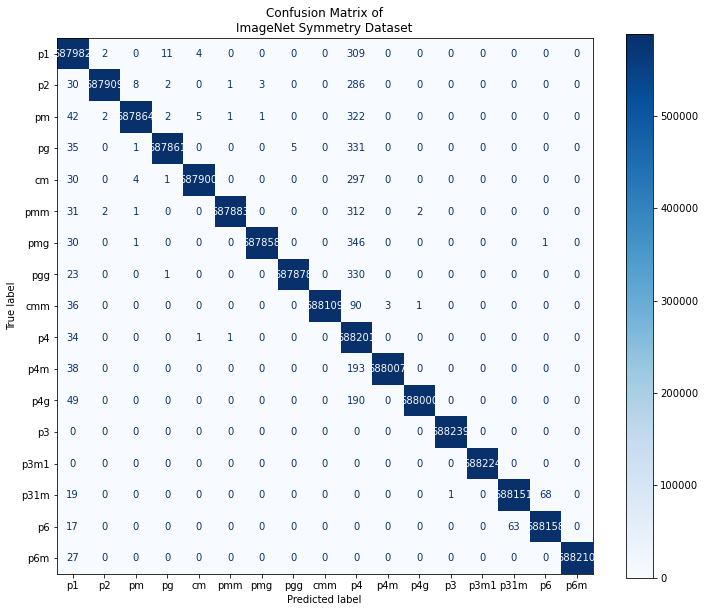

In [10]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [11]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 8696/8696 [27:55<00:00,  5.19it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.9991540067679459


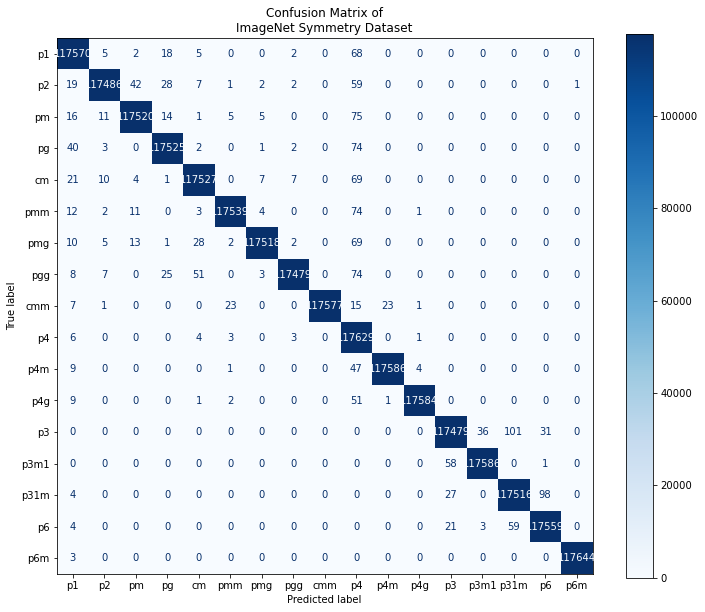

In [12]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nImageNet Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [13]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

100%|██████████| 1985/1985 [29:26<00:00,  1.12it/s]


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5805782531969523


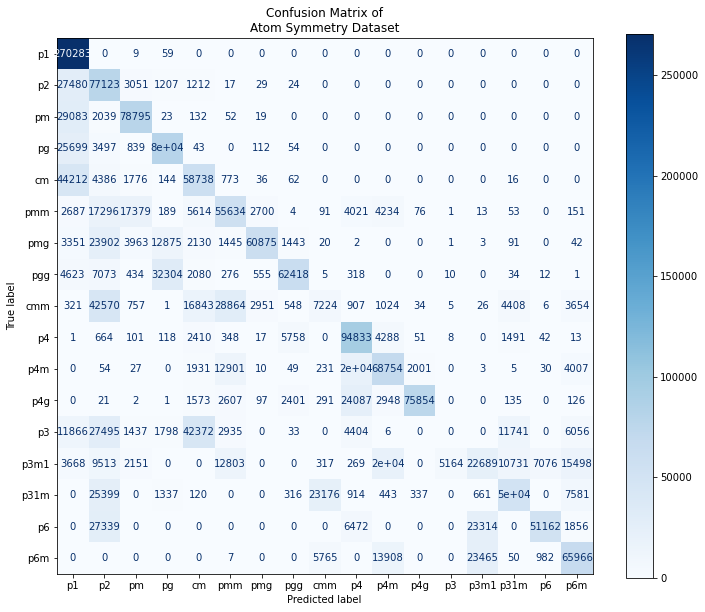

In [14]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, save_file=None, title='\nAtom Symmetry Dataset', style='simple')
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')